# BackPropogation

### deritative
df/da = how does change(slightlly) in a affects f

NN are just mathmaticall expressions. they take he input data and whights of the NN as input as a mathematical expression and the output are the predections of the neural net (or the loss function)

backpropogation is somthing really general(כלי מתמטי)

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]


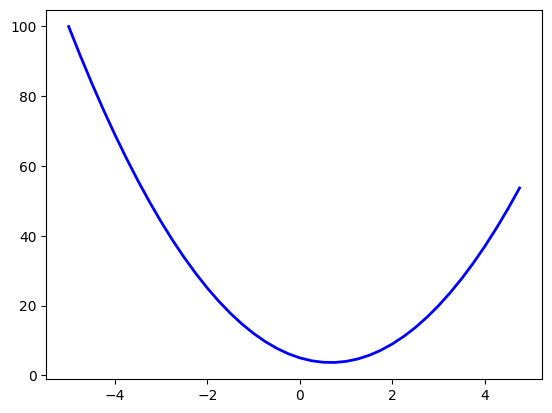

In [15]:
f(3.0)

xs = np.arange(-5,5,0.25)
print(xs)

ys = f(xs)
ys

plt.plot(xs,ys, color='blue', linewidth=2, label='f(x)')

Now lets figure what is the derivative of this function f(x) at any single point x ? 

we WILL NOT going to use the derivative expression we leard in high school. 
instead we will use: 

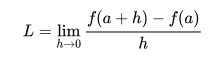

if we slightlly increase samll number h how does the function respond ? with what sensitivity does it respond ? what is the slope of that point ? 
slope = the function responding (does the function go up or down ? how much ? )

In [ ]:
h=0.001
x=3.0
f(x+h) # looking at the graph of the function we expect the f(x+h) > f(x) since the function is increasing at x=3.0

20.140299999999996

In [22]:
#the slope is: 
(f(x+h)-f(x))/h # to get the real value, h neeeds to very samll (h->0).the slope is negative. where x+h-x = h

14.029999999999632

In [23]:
#lets get more complex
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [ ]:
h = 0.0001


#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b + c
a +=h
d2 = a*b + c #d1 is bumped by a

print("d1", d1)
print('d2',d2)
print('slope', (d2-d1)/h) # this is the slope of the function d(a) = a*b + c at a=2.0
# d2-d1 is how much the function increasd when we bumped teh input we intrested in by tiny amount and this is mormilized by h(to get the slope) 
#increasing a is making d2 smaller
# this is df/da 

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


Now we need data structures to maintain the big big expresions of the NNs

In [ ]:
class Value:

    def __init__(self,data):
        self.data = data


    '''the __repr__ function helps us to see the value of the object when we print it out. 
    without it, we will see the memory address of the object.'''

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data) # new object is created
        return out

    def __mul__(self, other):
            out = Value(self.data * other.data) # new object is created
            return out

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
a + b # the same as a.__add__(b)
a*b # the same as a.__mul__(b)
a*b + c # the same as a.__mul__(b).__add__(c)


Value(data=4.0)

now, we want the conective tissue of this expression. we would want to keep the expresion graph so we will keep poiners about what values produce what other values. 

also, we want to know which operation created the value ( for d._prev we got: {Value(data=-6.0), Value(data=10.0)} we now a*b gave -6+10 = 4, but someone else would'nt know what operation between a*b and c gives 4 !)

In [73]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):# why op= '' ? becuse we want to have a default value for the _op parameter. if we don't provide a value for _op, it will be an empty string. this is useful because we can use the _op parameter to store the operation that created the current node.
        self.data = data
        self.grad = 0.0 # at initilazation we assume no impact does not effect ion the output. we will update the grad later when we do backpropagation.
        self._prev = set(_children) # is the set of children of the current node. it is a set because we don't want to have duplicates(efficency). 
        self._op = _op
        self.label = label # this is useful for visualization. we can use the label to store the name of the variable. 


    '''the __repr__ function helps us to see the value of the object when we print it out. 
    without it, we will see the memory address of the object.'''

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') # new object is created. (self, other) is the tuple of children of the current node.
        return out

    def __mul__(self, other):
            out = Value(self.data * other.data, (self, other), '*') # new object is created
            return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label='d' # the same as a.__mul__(b).__add__(c)
f= Value(-2.0, label='f')
L = d*f; L.label='L'
d


Value(data=4.0)

In [69]:
d._prev # this is the set of children of the current node

{Value(data=-6.0), Value(data=10.0)}

In [70]:
d._op

'+'

becuse the expression will be big, we would like a way to nicely visualize expressions the we're building out. lets look at a copy-paste scary code:

In [76]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges
  
def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)
      
  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
  return dot

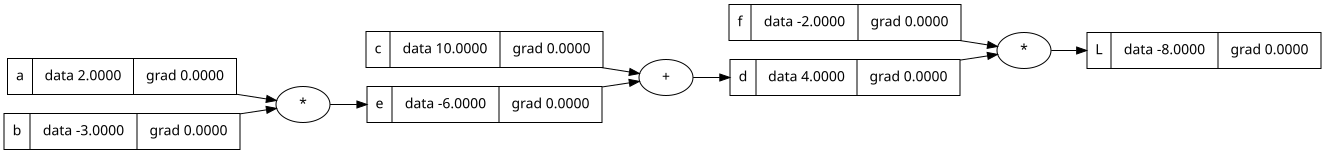

In [77]:
draw_dot(L)

Now we will do backprpogation. we wil start at the end(from L) snd we're going to reverse and calculate the gradient along all the intermediate value. 
for every sengle value we are going to calculate the derivative of that node with respect to L. 
the derivative of L with respect to L is 1, dL/df, dL/dd etc. 
in the NN setting we are very intrsetd in the derivative of this loss functio(L) with respect to the whights(here are a,b,c and f) of the NN. we would like to know how this whights are epecting the loss function. we want intrestend in the derivate of the output with respect to some of its lead nodes and the leaf nodes will be the wightes of the NN and the other leaf nodes will be the data itself. we usualy wont want or use the der of the L function with respect to input data cuz the data is fixed but the whites will be iterited using gradient information. 

אז לא הבנתי, כניסות הם עלים, אז אני לוקח רק חלק מהכניסות? כי כל העלים הם כניסות בוודאות, הם משתנים או משהו אחר ? 